### Load packages

In [1]:
from pathlib import Path
import scanpy as sc
import squidpy as sq
import liana as li
import pandas as pd
import os

## Load and Prep Data

In [2]:
# file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
# backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

# if os.path.exists(file_path):
#     adata = sc.read(file_path)
# else:
#     adata = sc.read(
#     file_path,
#     backup_url=backup_url
# )

# adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# adata.var_names = adata.var["gene_name"]
# adata.obsm['spatial'] = adata.obsm['X_spatial_coords']

In [3]:
# adata = sc.read("../../data/kuppe_heart19.h5ad", backup_url='https://figshare.com/ndownloader/files/41501073?private_link=4744950f8768d5c8f68c')
# adata.obs['cell_type'] = adata.obs['celltype_niche']

# # Rename to more informative names
# full_names = {'Adipo': 'Adipocytes',
#               'CM': 'Cardiomyocytes',
#               'Endo': 'Endothelial',
#               'Fib': 'Fibroblasts',
#               'PC': 'Pericytes',
#               'prolif': 'Proliferating',
#               'vSMCs': 'Vascular_SMCs',
#               }
# # but only for the ones that are in the data
# adata.obsm['compositions'].columns = [full_names.get(c, c) for c in adata.obsm['compositions'].columns]

In [4]:
# adata.layers['counts'] = adata.X.copy()
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

In [ ]:
data_path = Path("../../data/agne_cd/")
adata = sc.read_h5ad(data_path / "RUN1_SLIDE2_S6.h5ad")

adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()

adata.obs['cell_type'] = adata.obs['CellAnnotation.Level0']

In [6]:
adata.X.max()

8.644121072011853

... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical
... storing 'CellAnnotation.Level0' as categorical
... storing 'cell_type' as categorical


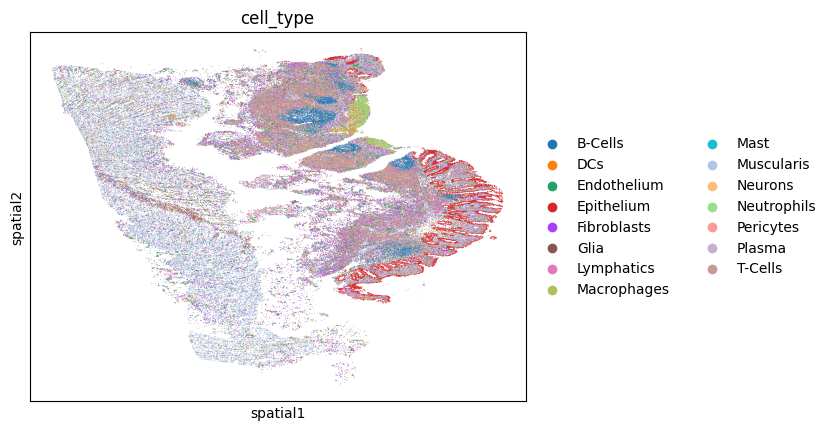

In [7]:
sc.pl.embedding(adata, basis="spatial", color=["cell_type"], wspace=0.4, s=1)

Use the chosen bandwidth based on this exploration to compute the final spatial connectivity matrix $W_{ij}$.

In [8]:
li.ut.spatial_neighbors(adata=adata, bandwidth=30)

#### Visualize proximity

Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


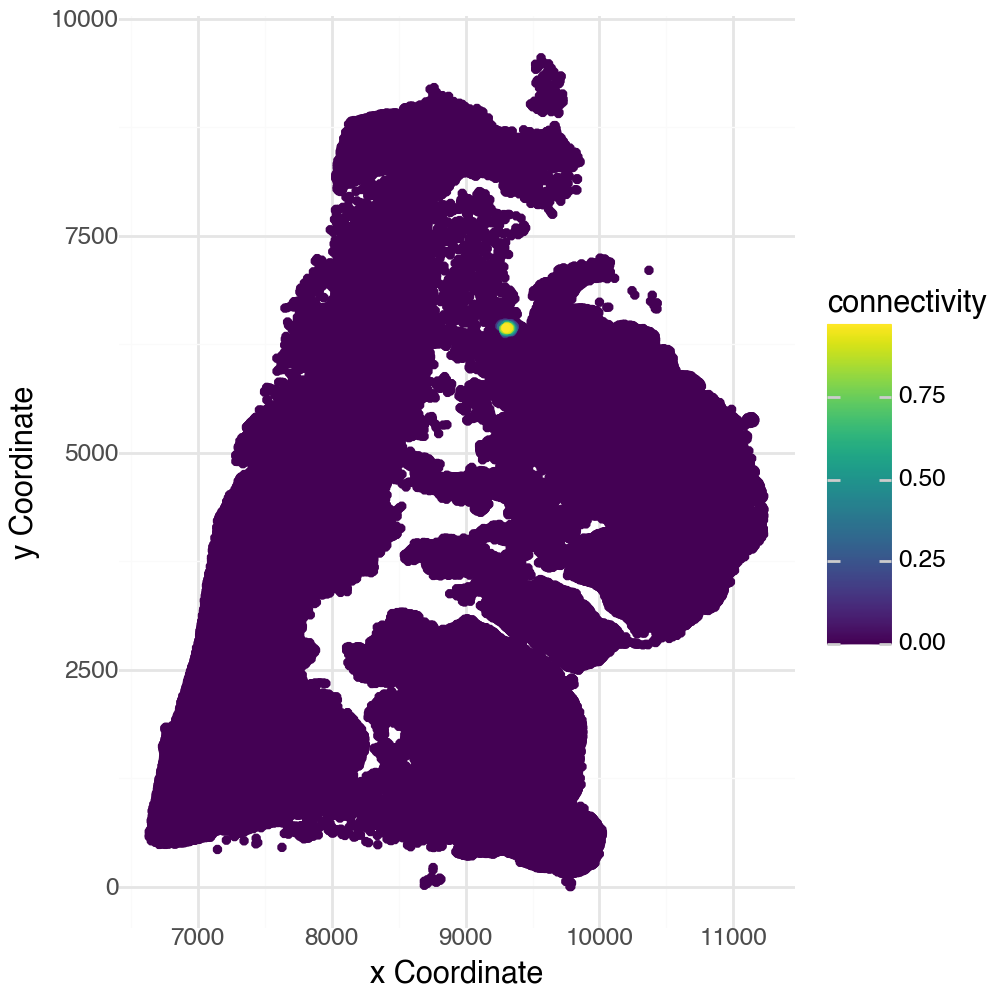

In [9]:
li.pl.connectivity(adata, idx=1000, size=1, figure_size=(5, 5))

### Find spatially variable genes (SVGs) using Morans'I

In [10]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [11]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
REG1A,0.463827,0.000000,1.599799e-07,0.000000
IL1B,0.458137,0.000000,1.599799e-07,0.000000
OLFM4,0.445979,0.000000,1.599799e-07,0.000000
HCAR3,0.439334,0.000000,1.599799e-07,0.000000
REG1B,0.433949,0.000000,1.599799e-07,0.000000
...,...,...,...,...
EIF5AL1,-0.000483,0.116225,1.599799e-07,0.130994
GRM2,-0.000540,0.090492,1.599799e-07,0.102832
ZHX3,-0.000541,0.090213,1.599799e-07,0.102560
INCA1,-0.000584,0.074006,1.599799e-07,0.084493


### Filter by spatially variable genes (SVGs)

In [12]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1629

In [13]:
adata = adata[:, svgs]

## Compute inflow score 

In [14]:
lrdata = li.mt.inflow(adata=adata, 
                resource_name='consensus', 
                groupby='cell_type',
                # obsm_key='compositions',
                use_raw=False,
                nz_prop=0.005
                )
lrdata.shape

/Users/b260-admin/miniforge3/envs/liana_squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/b260-admin/Repos/liana-py/src/liana/method/sp/_inflow.py:318: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


(191794, 5549)

### Optional: filter data to keep only spatially variable LR interaction

In [15]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [16]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

4703

In [17]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
Neutrophils^C3^ITGAX,0.383953,0.0,1.599799e-07,0.0
Neutrophils^CSF1^CSF3R,0.391347,0.0,1.599799e-07,0.0
Macrophages^LAMB3^CD44,0.393960,0.0,1.599799e-07,0.0
B-Cells^CD22^PTPRC,0.401462,0.0,1.599799e-07,0.0
B-Cells^ST6GAL1^CD22,0.411058,0.0,1.599799e-07,0.0
DCs^SPP1^CD44,0.421194,0.0,1.599799e-07,0.0
B-Cells^CXCL12^CXCR4,0.424790,0.0,1.599799e-07,0.0
Macrophages^SPP1^CD44,0.432970,0.0,1.599799e-07,0.0
B-Cells^C3^CD19,0.470334,0.0,1.599799e-07,0.0
B-Cells^CXCL14^CXCR4,0.471503,0.0,1.599799e-07,0.0


### Convert lrdata to muData

In [18]:
import scanpy as sc
import mudata as md
import anndata as an
import numpy as np
from tqdm import tqdm

from liana._constants import DefaultValues as V
from liana.method._pipe_utils._pre import _choose_mtx_rep
from liana._docs import d
from liana._logging import _logg


def split_to_mdata(
    adata,
    lr_sep = V.lr_sep,
    vars_per_cell = None,
    cells_per_var = V.min_cells,
    keep_view_vars = 10,
    keep_view_obs_prop = 0.1,
    use_raw = V.use_raw,
    layer = V.layer,
    verbose = V.verbose,
):
    """
    Split AnnData object into MultiData object by variable name prefixes.

    Args:
    ----------
    %(adata)s
    %(lr_sep)s
        Separator used in variable names to split views (e.g., 'ligand^receptor').
    vars_per_cell
        Minimum number of variables that should be present per cell (filtering within views).
    cells_per_var
        Minimum number of cells that should express each variable (filtering within views).
    keep_view_vars
        Minimum number of variables required for a view to be kept. Default is 10.
    keep_view_obs_prop
        Minimum proportion of original cells required for a view to be kept. Default is 0.1.
    %(use_raw)s
    %(layer)s
    %(verbose)s

    Returns
    -------
        MultiData: A new MultiData object with views split by variable name prefixes.
    """

    adata_dict = {}
    n_original_cells = adata.n_obs
    min_view_cells = int(n_original_cells * keep_view_obs_prop)
    
    # Extract views from variable name prefixes before the `lr_sep` separator
    views = adata.var.index.str.split(lr_sep, expand=True).get_level_values(0).unique().tolist()

    for view in tqdm(views, desc="Processing views", disable=not verbose):

        # Filter variables (genes) belonging to the current view
        var_filter = adata.var.index.str.startswith(f"{view}{lr_sep}")
        adata_mod = adata[:, var_filter].copy()
        
        # Get sparse matrix representation
        X = _choose_mtx_rep(adata_mod, use_raw=use_raw, layer=layer, verbose=False)

        # Filter by genes (cells_per_var): count non-zero elements per gene across cells
        if cells_per_var is not None:
            gene_counts = X.getnnz(axis=0)
            gene_mask = gene_counts >= cells_per_var
            X = X[:, gene_mask]
            adata_mod = adata_mod[:, gene_mask].copy()
        
        # Filter by cells (vars_per_cell): count non-zero elements per cell across genes
        if vars_per_cell is not None:
            cell_counts = X.getnnz(axis=1)
            cell_mask = cell_counts >= vars_per_cell
            X = X[cell_mask, :]
            adata_mod = adata_mod[cell_mask, :].copy()
        
        # Update X in adata_mod
        adata_mod.X = X

        # Check if view meets minimum requirements
        if adata_mod.n_vars >= keep_view_vars and adata_mod.n_obs >= min_view_cells:
            adata_dict[view] = adata_mod
            _logg(f"{view}: {adata_mod.n_obs} cells, {adata_mod.n_vars} vars after filtering.", verbose=verbose)
        else:
            _logg(f"{view} excluded: {adata_mod.n_obs} cells < {min_view_cells} or {adata_mod.n_vars} vars < {keep_view_vars}", level='warn', verbose=verbose)

    # Create MuData object with filtered views
    mdata = md.MuData(adata_dict)
    
    # Find intersecting observations
    intersecting_obs = adata.obs.index.intersection(mdata.obs.index)
    if len(intersecting_obs) > 0:
        # Subset adata to intersecting observations and copy obsm
        mdata.obsm = adata[intersecting_obs].obsm.copy()
        mdata.obs = adata[intersecting_obs].obs.copy()
        
    else:
        if verbose:
            _logg("No intersecting observations found between adata and mdata", level='warn', verbose=verbose)
    
    return mdata

In [19]:
# lrdata_path  = Path("../../data/MERFISH_mouse_brain/")
# adata = sc.read_h5ad(lrdata_path / "lrdata_C57BL6J_2.039.h5ad")

In [20]:
lrdata.X

<191794x4703 sparse matrix of type '<class 'numpy.float64'>'
	with 5823422 stored elements in Compressed Sparse Row format>

In [21]:
# subset to random 20k cells
# lrdata = lrdata[lrdata.obs.sample(n=2000, random_state=42).index,:].copy()

In [22]:
sc.pp.filter_cells(lrdata, min_genes=20)

/Users/b260-admin/miniforge3/envs/liana_squidpy/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [23]:
lrdata

AnnData object with n_obs × n_vars = 100810 × 4703
    obs: 'cell', 'x', 'y', 'SAMPLE', 'TYPE', 'LOCATION', 'CellAnnotation.Level3', 'CellAnnotation.Level0', 'nCount_XENIUM_clean', 'nFeature_XENIUM_clean', 'cell_type', 'n_genes'
    var: 'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
    uns: 'cell_type_colors', 'moranI'
    obsm: 'X_umap', 'spatial'
    obsp: 'spatial_connectivities'

In [24]:
mdata = split_to_mdata(lrdata,
               lr_sep="^",
               use_raw=False,
               layer=None,
               vars_per_cell = None,
               cells_per_var = V.min_cells,
               keep_view_vars = 10,
               keep_view_obs_prop = 0.1,
               verbose=True
               )

Processing views:   0%|          | 0/15 [00:00<?, ?it/s]B-Cells: 100810 cells, 295 vars after filtering.
Macrophages: 100810 cells, 357 vars after filtering.
Processing views:  13%|█▎        | 2/15 [00:00<00:00, 18.52it/s]DCs: 100810 cells, 353 vars after filtering.
Neutrophils: 100810 cells, 204 vars after filtering.
Processing views:  27%|██▋       | 4/15 [00:00<00:00, 17.22it/s]Lymphatics: 100810 cells, 329 vars after filtering.
Neurons: 100810 cells, 157 vars after filtering.
Fibroblasts: 100810 cells, 361 vars after filtering.
Processing views:  47%|████▋     | 7/15 [00:00<00:00, 18.43it/s]T-Cells: 100810 cells, 341 vars after filtering.
Plasma: 100810 cells, 342 vars after filtering.
Processing views:  60%|██████    | 9/15 [00:00<00:00, 16.24it/s]Muscularis: 100810 cells, 324 vars after filtering.
Epithelium: 100810 cells, 286 vars after filtering.
Pericytes: 100810 cells, 329 vars after filtering.
Processing views:  80%|████████  | 12/15 [00:00<00:00, 16.80it/s]Glia: 100810 cell

In [25]:
import muon as mu

/Users/b260-admin/miniforge3/envs/liana_squidpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
/Users/b260-admin/miniforge3/envs/liana_squidpy/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead


In [26]:
mu.tl.mofa(mdata,
           use_obs='union',
           convergence_mode='medium',
           n_factors=15,
           seed=1337,
           outfile='models/mofacellx.h5ad',
        #    use_var='highly_variable'
           )


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='B-Cells' group='group1' with N=100810 samples and D=295 features...
Loaded view='Macrophages' group='group1' with N=100810 samples and D=357 features...
Loaded view='DCs' group='group1' with N=100810 samples and D=353 features...
Loaded view='Neutrophils' group='group1' with N=100810 samples and D=204 features...
Loaded view='Lymphatics' group='group1' with N=100810

In [27]:
adata = sc.AnnData(obs = mdata.obs, obsm=mdata.obsm)

In [30]:
import scanpy as sc

In [32]:

sc.pp.neighbors(adata, use_rep='X_mofa')
sc.tl.umap(adata)

In [33]:
adata.obs

,cell,x,y,SAMPLE,TYPE,LOCATION,CellAnnotation.Level3,CellAnnotation.Level0,nCount_XENIUM_clean,nFeature_XENIUM_clean,cell_type,n_genes
CR0f5fda56f-1005,CR0f5fda56f-1005,9256.619126,15645.616528,RUN1_SLIDE2_S6,ULCER,ILEUM,Monocytes CCR2+,Macrophages,200.0,176,Macrophages,26
CR0f5fda56f-1007,CR0f5fda56f-1007,8988.678413,15922.350740,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,378.0,256,Fibroblasts,43
CR0f5fda56f-101,CR0f5fda56f-101,9155.494838,14869.435363,RUN1_SLIDE2_S6,ULCER,ILEUM,Extraganglionic Glia,Glia,462.0,333,Glia,50
CR0f5fda56f-1014,CR0f5fda56f-1014,9024.010598,15876.458288,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,97.0,73,Fibroblasts,23
CR0f5fda56f-1015,CR0f5fda56f-1015,9262.321313,15647.175789,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,414.0,301,Fibroblasts,33
...,...,...,...,...,...,...,...,...,...,...,...,...
CRf3c5992a7-991,CRf3c5992a7-991,7651.243894,19844.387213,RUN1_SLIDE2_S6,ULCER,ILEUM,Stromal 3,Fibroblasts,73.0,59,Fibroblasts,28
CRf3c5992a7-9927,CRf3c5992a7-9927,7591.136991,20505.229893,RUN1_SLIDE2_S6,ULCER,ILEUM,Pericytes,Pericytes,85.0,69,Pericytes,32
CRf3c5992a7-994,CRf3c5992a7-994,7557.601128,19935.729311,RUN1_SLIDE2_S6,ULCER,ILEUM,Inner Muscularis,Muscularis,169.0,134,Muscularis,35
CRf3c5992a7-998,CRf3c5992a7-998,7548.652679,19948.950000,RUN1_SLIDE2_S6,ULCER,ILEUM,Pericytes,Pericytes,68.0,57,Pericytes,24


... storing 'SAMPLE' as categorical
... storing 'TYPE' as categorical
... storing 'LOCATION' as categorical
... storing 'CellAnnotation.Level3' as categorical
... storing 'CellAnnotation.Level0' as categorical
... storing 'cell_type' as categorical


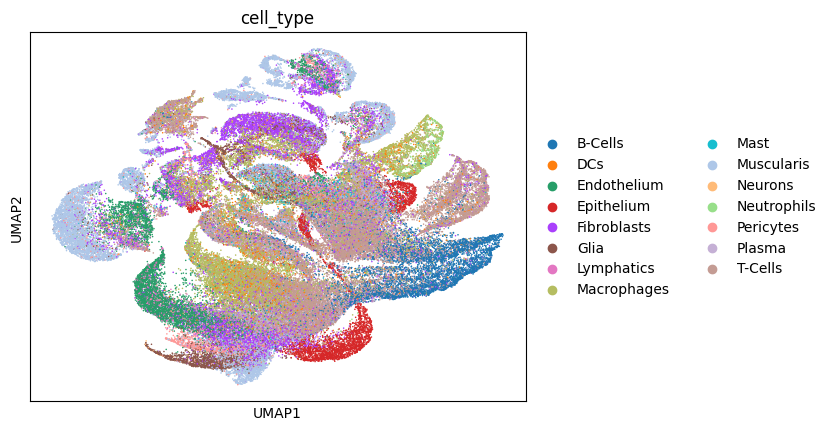

In [34]:
sc.pl.umap(adata, color=['cell_type'], s=5)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [38]:
X = adata.obsm["X_mofa"]  
y = adata.obs["cell_type"].values
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

In [40]:
rf = RandomForestClassifier(
    n_estimators=300,
#    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [41]:
# Evaluation
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.7152068247197698
              precision    recall  f1-score   support

     B-Cells       0.75      0.77      0.76      1290
         DCs       0.27      0.01      0.02       644
 Endothelium       0.79      0.85      0.82      1397
  Epithelium       0.89      0.95      0.92       795
 Fibroblasts       0.63      0.63      0.63      2513
        Glia       0.77      0.70      0.74       759
  Lymphatics       0.64      0.14      0.23       443
 Macrophages       0.65      0.74      0.69      2638
        Mast       0.36      0.11      0.17       342
  Muscularis       0.79      0.84      0.81      2488
     Neurons       1.00      0.24      0.38        17
 Neutrophils       0.54      0.31      0.39       111
   Pericytes       0.63      0.44      0.51       620
      Plasma       0.62      0.53      0.57      1281
     T-Cells       0.72      0.88      0.79      4824

    accuracy                           0.72     20162
   macro avg       0.67      0.54      0.56     201

In [42]:
from sklearn.metrics import roc_auc_score

y_proba = rf.predict_proba(X_test)

auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC (macro):   ", auc_macro)
print("ROC-AUC (weighted):", auc_weighted)

ROC-AUC (macro):    0.9370506076244143
ROC-AUC (weighted): 0.9415550711304397


In [43]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

per_class_auc = roc_auc_score(
    y_test_bin,
    y_proba,
    average=None
)

for cls, auc in zip(le.classes_, per_class_auc):
    print(f"{cls}: AUC = {auc:.3f}")


B-Cells: AUC = 0.971
DCs: AUC = 0.837
Endothelium: AUC = 0.979
Epithelium: AUC = 0.999
Fibroblasts: AUC = 0.893
Glia: AUC = 0.974
Lymphatics: AUC = 0.848
Macrophages: AUC = 0.940
Mast: AUC = 0.900
Muscularis: AUC = 0.974
Neurons: AUC = 0.994
Neutrophils: AUC = 0.953
Pericytes: AUC = 0.925
Plasma: AUC = 0.918
T-Cells: AUC = 0.951


In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

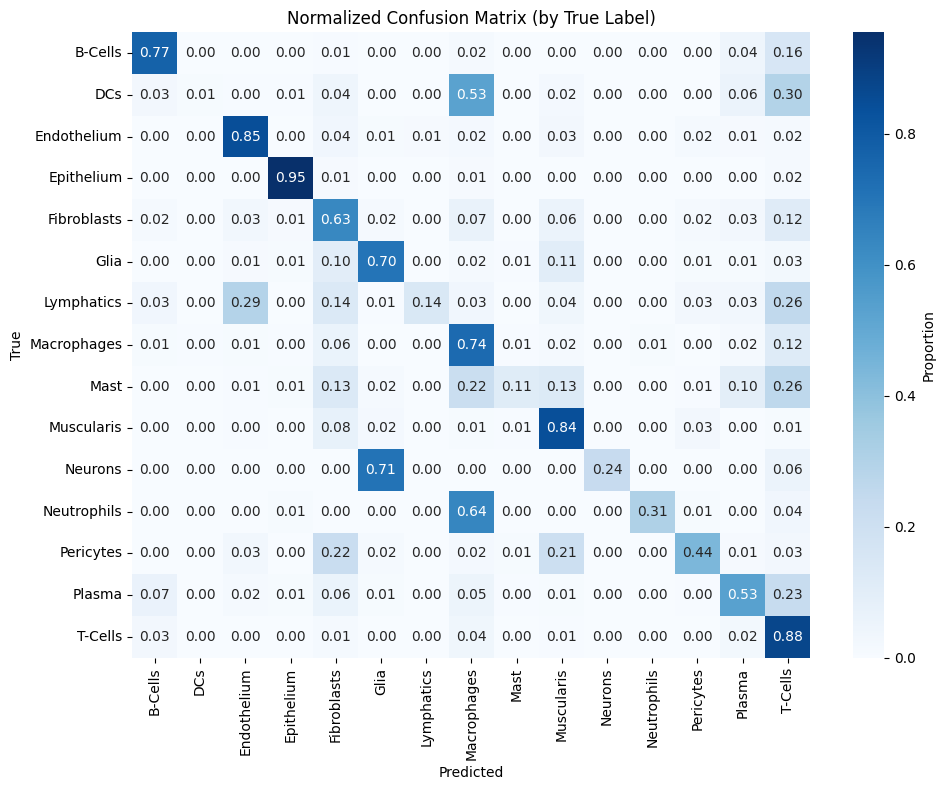

In [45]:
# Normalized confusion matrix (shows which labels are confused)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cbar_kws={'label': 'Proportion'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (by True Label)')
plt.tight_layout()
plt.show()